# 01 - Dataset Preparation

This notebook prepares the NEU Surface Defect Dataset for all final experiments.

Tasks:
- Inspect dataset structure
- Count images in each class
- Check corrupted images
- Inspect image dimensions
- Visualize sample images
- Create a fixed train/validation/test split
- Save split information for reproducibility

In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
from pathlib import Path

PROJECT_DIR = Path(
    "/content/drive/MyDrive/e23-co5430-Surface-Defect-Detection"
)

RAW_DIR = PROJECT_DIR / "dataset" / "raw"
SPLIT_DIR = PROJECT_DIR / "dataset" / "split"

MODELS_DIR = PROJECT_DIR / "models"
RESULTS_DIR = PROJECT_DIR / "results"

print("Project exists:", PROJECT_DIR.exists())
print("Raw dataset exists:", RAW_DIR.exists())

Project exists: True
Raw dataset exists: True


In [4]:
import random
import shutil
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

RANDOM_SEED = 42
random.seed(RANDOM_SEED)

class_names = sorted([
    folder.name
    for folder in RAW_DIR.iterdir()
    if folder.is_dir()
])

print(class_names)

['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled_in_scale', 'scratches']


In [5]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp"}

class_counts = {}

for class_name in class_names:
    class_dir = RAW_DIR / class_name

    images = [
        file
        for file in class_dir.iterdir()
        if file.suffix.lower() in IMAGE_EXTENSIONS
    ]

    class_counts[class_name] = len(images)

counts_df = pd.DataFrame(
    list(class_counts.items()),
    columns=["Class", "Image Count"]
)

display(counts_df)

print("Total images:", sum(class_counts.values()))

,Class,Image Count
0,crazing,300
1,inclusion,300
2,patches,300
3,pitted_surface,300
4,rolled_in_scale,300
5,scratches,300


Total images: 1800


In [6]:
corrupted_files = []

for class_name in class_names:
    class_dir = RAW_DIR / class_name

    for image_path in class_dir.iterdir():
        if image_path.suffix.lower() not in IMAGE_EXTENSIONS:
            continue

        try:
            with Image.open(image_path) as img:
                img.verify()
        except Exception:
            corrupted_files.append(str(image_path))

print("Corrupted images:", len(corrupted_files))

for file in corrupted_files[:10]:
    print(file)

Corrupted images: 0


,width,height,mode,count
0,200,200,RGB,1800


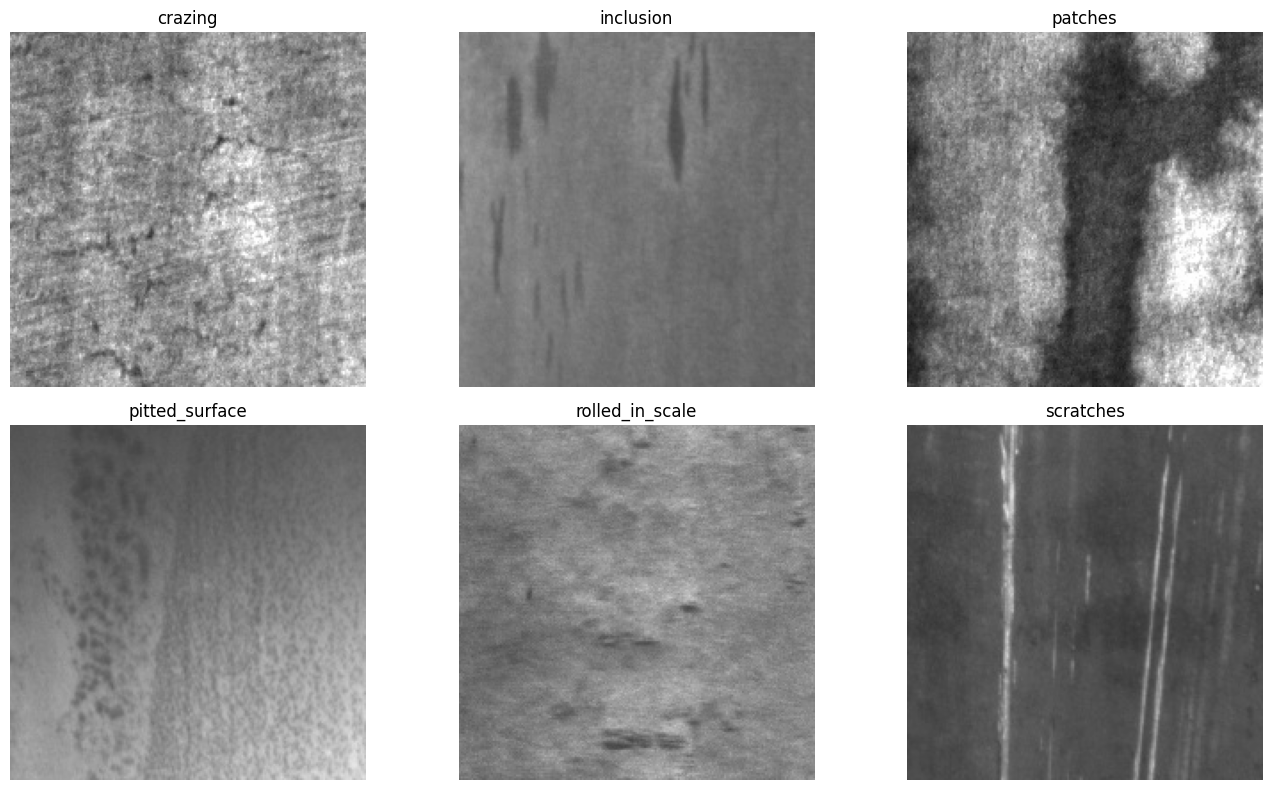

In [7]:
image_info = []

for class_name in class_names:
    class_dir = RAW_DIR / class_name

    for image_path in class_dir.iterdir():
        if image_path.suffix.lower() not in IMAGE_EXTENSIONS:
            continue

        with Image.open(image_path) as img:
            image_info.append({
                "class": class_name,
                "width": img.width,
                "height": img.height,
                "mode": img.mode
            })

image_info_df = pd.DataFrame(image_info)

display(
    image_info_df.groupby(
        ["width", "height", "mode"]
    ).size().reset_index(name="count")
)

plt.figure(figsize=(14, 8))

for i, class_name in enumerate(class_names):
    class_dir = RAW_DIR / class_name

    image_files = [
        file
        for file in class_dir.iterdir()
        if file.suffix.lower() in IMAGE_EXTENSIONS
    ]

    selected = random.choice(image_files)

    with Image.open(selected) as img:
        plt.subplot(2, 3, i + 1)
        plt.imshow(img, cmap="gray")
        plt.title(class_name)
        plt.axis("off")

plt.tight_layout()
plt.show()

In [8]:
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

if SPLIT_DIR.exists():
    shutil.rmtree(SPLIT_DIR)

SPLIT_DIR.mkdir(parents=True, exist_ok=True)

for split_name in ["train", "validation", "test"]:
    for class_name in class_names:
        folder = SPLIT_DIR / split_name / class_name
        folder.mkdir(parents=True, exist_ok=True)

split_records = []

for class_name in class_names:
    source_dir = RAW_DIR / class_name

    images = [
        file
        for file in source_dir.iterdir()
        if file.suffix.lower() in IMAGE_EXTENSIONS
    ]

    rng = random.Random(RANDOM_SEED)
    rng.shuffle(images)

    total = len(images)

    train_end = int(total * TRAIN_RATIO)
    val_end = train_end + int(total * VAL_RATIO)

    train_images = images[:train_end]
    val_images = images[train_end:val_end]
    test_images = images[val_end:]

    split_groups = {
        "train": train_images,
        "validation": val_images,
        "test": test_images
    }

    for split_name, files in split_groups.items():

        destination_dir = SPLIT_DIR / split_name / class_name

        for file in files:

            shutil.copy2(
                file,
                destination_dir / file.name
            )

            split_records.append({
                "filename": file.name,
                "class": class_name,
                "split": split_name
            })


split_df = pd.DataFrame(split_records)

summary = (
    split_df.groupby(["class", "split"])
    .size()
    .unstack(fill_value=0)
)

display(summary)

print("Total:", len(split_df))

split,test,train,validation
class,,,
crazing,45,210,45
inclusion,45,210,45
patches,45,210,45
pitted_surface,45,210,45
rolled_in_scale,45,210,45
scratches,45,210,45


Total: 1800


In [9]:
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

split_df.to_csv(
    RESULTS_DIR / "dataset_split.csv",
    index=False
)

for split_name in ["train", "validation", "test"]:

    subset = split_df[
        split_df["split"] == split_name
    ]

    subset.to_csv(
        RESULTS_DIR / f"{split_name}_files.csv",
        index=False
    )